# Interacting with SQL Databases Using Langchain's SQL Agents

## Libraries and Settings

In [11]:
# Libraries
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from langchain_classic.agents.agent_types import AgentType
from langchain_community.agent_toolkits import (
    SQLDatabaseToolkit,
    create_sql_agent,
)
from langchain_community.utilities import SQLDatabase
from langchain_openai import ChatOpenAI
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")

# Read OpenAI API key
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    print("Please provide your OpenAI API key in the .env file.")

# Settings

# Current working directory
print(os.getcwd())


/workspaces/python_postgresql_langchain


## Read apartment data to data frame

In [ ]:
# Read apartment data
df = pd.read_csv("apartments_data_prepared.csv", sep=",")
df.head(5)


,web-scraper-order,web-scraper-start-url,rooms_area_price_raw,address_raw,price_raw,description_raw,text_raw,rooms,area,price
0,1662023695-433,https://www.immoscout24.ch/de/wohnung/mieten/k...,"3,5 Zimmer, 122 m², CHF 3180.—","Sunnenbergstrasse 15, 8633 Wolfhausen, ZH",CHF 3180.—,"«Grosse Galerie, Terrasse mit Pergola, Berg- u...","3,5 Zimmer, 122 m², CHF 3180.—Sunnenbergstrass...",3.5,122.0,3180.0
1,1662023745-820,https://www.immoscout24.ch/de/wohnung/mieten/k...,"2,5 Zimmer, 78 m², CHF 3760.—","Lavaterstr. 63, 8002 Zürich, ZH",CHF 3760.—,«Wunderschöne Wohnung im Enge-Quartier»,"2,5 Zimmer, 78 m², CHF 3760.—Lavaterstr. 63, 8...",2.5,78.0,3760.0
2,1662023742-807,https://www.immoscout24.ch/de/wohnung/mieten/k...,"5,5 Zimmer, 115 m², CHF 2860.—","Langfurrenstrasse 5c, 8623 Wetzikon ZH, ZH",CHF 2860.—,«Wohnmomente zum Festhalten»,"5,5 Zimmer, 115 m², CHF 2860.—Langfurrenstrass...",5.5,115.0,2860.0
3,1662023804-1290,https://www.immoscout24.ch/de/wohnung/mieten/k...,"3,5 Zimmer, 74 m², CHF 2165.—","Sandbuckweg 5A, 8157 Dielsdorf, ZH",CHF 2165.—,"«3,5 pièces, 74 m²»","top3,5 Zimmer, 74 m², CHF 2165.—Sandbuckweg 5A...",3.5,74.0,2165.0
4,1662023739-771,https://www.immoscout24.ch/de/wohnung/mieten/k...,"5,5 Zimmer, 195 m², CHF 6900.—","Parkring 59, 8002 Zürich, ZH",CHF 6900.—,«Wohnanlage Im Parkring - Exklusive Wohnung zu...,"5,5 Zimmer, 195 m², CHF 6900.—Parkring 59, 800...",5.5,195.0,6900.0


## Create database connection

In [13]:
# Set up database connection
user = "pgadmin"
password = "geheim"
host = "localhost"
port = "5432"
database = "postgres"

# Create Connection URL
db_connection_url = (
    "postgresql://"
    + user
    + ":"
    + password
    + "@"
    + host
    + ":"
    + port
    + "/"
    + database
)

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Test database connection
with engine.connect() as connection:
    result = connection.execute(text("SELECT current_database()"))
    print(result.fetchone())

# Dispose the engine
engine.dispose()


('postgres',)


## Write data to database

In [14]:
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df.to_sql("apartment_table", engine, if_exists="replace")

# Dispose the engine
engine.dispose()


## List tables in the database

In [15]:
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Open a connection
with engine.connect() as connection:
    # Execute the query
    result = connection.execute(
        text(
            """SELECT table_name
            FROM information_schema.tables
            WHERE table_schema = 'public'"""
        )
    )

    # Fetch and print the results
    for row in result:
        print(row[0])

# Dispose the engine
engine.dispose()


geography_columns
geometry_columns
spatial_ref_sys
apartment_table


## Make standard SQL query to select data

In [16]:
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query(
    """SELECT
    address_raw,
    rooms,
    area,
    price
    FROM apartment_table
    WHERE price >= 1000""",
    con=engine,
)

# Dispose the engine
engine.dispose()

# Show the data
df_sub.head()


,address_raw,rooms,area,price
0,"Sunnenbergstrasse 15, 8633 Wolfhausen, ZH",3.5,122.0,3180.0
1,"Lavaterstr. 63, 8002 Zürich, ZH",2.5,78.0,3760.0
2,"Langfurrenstrasse 5c, 8623 Wetzikon ZH, ZH",5.5,115.0,2860.0
3,"Sandbuckweg 5A, 8157 Dielsdorf, ZH",3.5,74.0,2165.0
4,"Parkring 59, 8002 Zürich, ZH",5.5,195.0,6900.0


## Count number of apartments in table

In [17]:
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Count number of apartments
count_query = """SELECT COUNT(*) as apartment_count
FROM apartment_table"""

# Execute the query and fetch the result
result = pd.read_sql_query(count_query, con=engine)

# Dispose the engine
engine.dispose()

# Show the count
print("Number of apartments:", result["apartment_count"].iloc[0])


Number of apartments: 1008


## Calculate average price of selected apartments

In [18]:
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Query to get the average price of selected apartments
query = """SELECT AVG(price) as average_price
FROM apartment_table
WHERE rooms = 3.5
AND area >= 100"""

# Execute the query and fetch the result
result = pd.read_sql_query(query, con=engine)

# Dispose the engine
engine.dispose()

# Show the average price
average_price = result["average_price"].iloc[0]
print(
    "Average price of apartments with 3.5 rooms and >= 100m² living area:",
    f"{average_price:.4f}",
)


Average price of apartments with 3.5 rooms and >= 100m² living area: 2905.7021


## Plot apartment prices

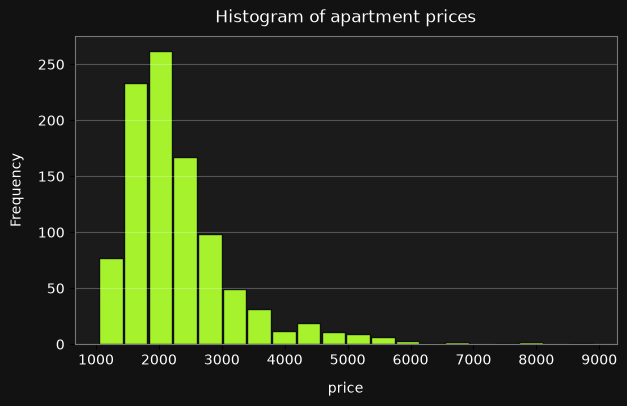

In [19]:
# Plot Histogram
fig = plt.figure(figsize=(7, 4), facecolor="#121212")
ax = plt.gca()
ax.set_facecolor("#1b1b1b")

n, bins, patches = plt.hist(
    x=df_sub["price"],
    bins=20,
    color="greenyellow",
    edgecolor="#0b0b0b",
    alpha=0.95,
    rwidth=0.95,
)

plt.grid(axis="y", alpha=0.25, color="white")
plt.ticklabel_format(style="plain")
plt.xlabel("price", fontsize=10, labelpad=10, color="white")
plt.ylabel("Frequency", fontsize=10, labelpad=10, color="white")
plt.title(
    "Histogram of apartment prices",
    fontsize=12,
    pad=10,
    color="white",
)
plt.xticks(fontsize=10, color="white")
plt.yticks(fontsize=10, color="white")

for spine in ax.spines.values():
    spine.set_color("#777777")

plt.show()


## Use an SQL Database Agent with LangChain to query the database

### Instantiate the LLM

In [20]:
# Initialize the OpenAI language model
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_tokens=256,
    max_retries=0,
    timeout=20,
    api_key=api_key,
)


### Create the SQL agent executor

In [21]:
# Create SQLAlchemy Engine
db = SQLDatabase.from_uri(db_connection_url)

# Create the SQL agent executor
agent_executor = create_sql_agent(
    llm=llm,
    toolkit=SQLDatabaseToolkit(db=db, llm=llm),
    verbose=False,
    agent_type=AgentType.OPENAI_FUNCTIONS,
    max_iterations=10,
    max_execution_time=60,
)


### Let the agent query the database (1st example)

In [22]:
# Define the question
agent_executor.invoke(
    {
        "input": """Describe the table apartment_table.
        Format the text."""
    }
)["output"]


OpenAIAuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************cPoA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

### Let the agent query the database (2nd example)

In [ ]:
# Define the question
agent_executor.invoke(
    {
        "input": """How many unique apartments are in the table
        apartment_table?
        Answer with: The number of unique apartments is ..."""
    }
)["output"]


### Let the agent query the database (3nd example)

In [ ]:
agent_executor.invoke(
    {
        "input": """What is the average price of apartments with 3.5 rooms
        and >= 100m2 living area in the table apartment_table?
        Round the result to two decimal places."""
    }
)["output"]


### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [ ]:
import os
import platform
from datetime import datetime
from platform import python_version

print("-----------------------------------")
print(os.name.upper())
print(platform.system(), "|", platform.release())
print("Datetime:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python Version:", python_version())
print("-----------------------------------")
